# Ejercicio 04 · Clasificador visual con CNN y Model Card

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Unidad II

Integra LAB07 sobre el proyecto base `INF8239_U02_CV_Proyecto_Base`. El entrenamiento completo se ejecuta con `uv run python scripts/train_cv.py` (unos 5 minutos en CPU) y guarda modelos y evidencias. Este cuaderno recalcula la auditoría y la partición, carga los modelos guardados y vuelve a evaluarlos en prueba.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Image, display
from sklearn.metrics import accuracy_score

from inf8239_u02_cv.data import CLASS_NAMES, audit_arrays, normalize_images, split_train_valid
from inf8239_u02_cv.evaluation import f1_macro, per_class, top_confusions

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
REPORTS = ROOT / "reports"
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## 1. Auditoría

In [2]:
(x_train_raw, y_train_all), (x_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()
audit = audit_arrays(x_train_raw, y_train_all, x_test_raw, y_test)
audit

{'forma_entrenamiento': [60000, 28, 28],
 'forma_prueba': [10000, 28, 28],
 'tipo': 'uint8',
 'rango_pixeles': [0, 255],
 'media_pixel_entrenamiento': 0.286,
 'desviacion_pixel_entrenamiento': 0.353,
 'clases_entrenamiento': {'T-shirt/top': 6000,
  'Trouser': 6000,
  'Pullover': 6000,
  'Dress': 6000,
  'Coat': 6000,
  'Sandal': 6000,
  'Shirt': 6000,
  'Sneaker': 6000,
  'Bag': 6000,
  'Ankle boot': 6000},
 'clases_prueba': {'T-shirt/top': 1000,
  'Trouser': 1000,
  'Pullover': 1000,
  'Dress': 1000,
  'Coat': 1000,
  'Sandal': 1000,
  'Shirt': 1000,
  'Sneaker': 1000,
  'Bag': 1000,
  'Ankle boot': 1000},
 'duplicados_en_entrenamiento': 0,
 'duplicados_en_prueba': 0,
 'entrenamiento_repetido_en_prueba': 0,
 'etiquetas_contradictorias': 0,
 'imagenes_vacias': 0}

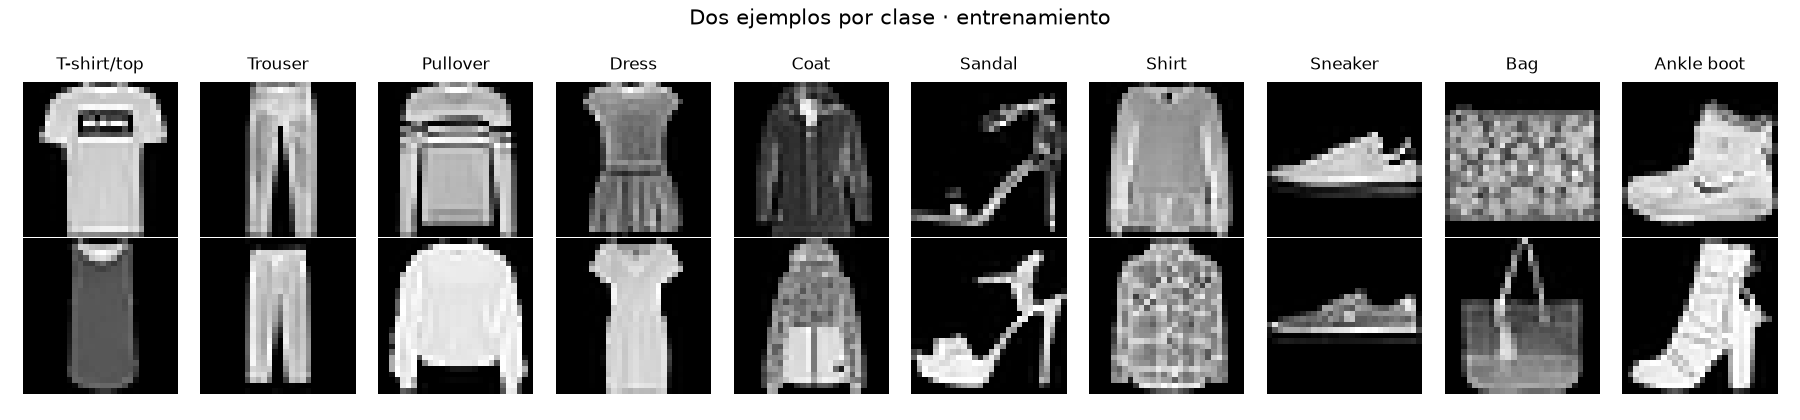

In [3]:
Image(filename=str(REPORTS / 'muestras.png'))

**Observación.** 60 000 imágenes de entrenamiento y 10 000 de prueba, 6000/1000 por clase, sin duplicados exactos ni imágenes compartidas entre entrenamiento y prueba.

## 2. Partición reproducible
La validación (6000 imágenes, estratificada, semilla 42) sale solo del entrenamiento oficial. La prueba oficial no se toca hasta el final.

In [4]:
train_idx, valid_idx = split_train_valid(x_train_raw, y_train_all, random_state=42)
saved = np.loadtxt(REPORTS / "indices_validacion.csv", skiprows=1, dtype=int)
assert np.array_equal(valid_idx, saved), "La partición no coincide con la guardada"
print(len(train_idx), len(valid_idx), np.bincount(y_train_all[valid_idx]))

54000 6000 [600 600 600 600 600 600 600 600 600 600]


## 3. Curvas de entrenamiento y decisión

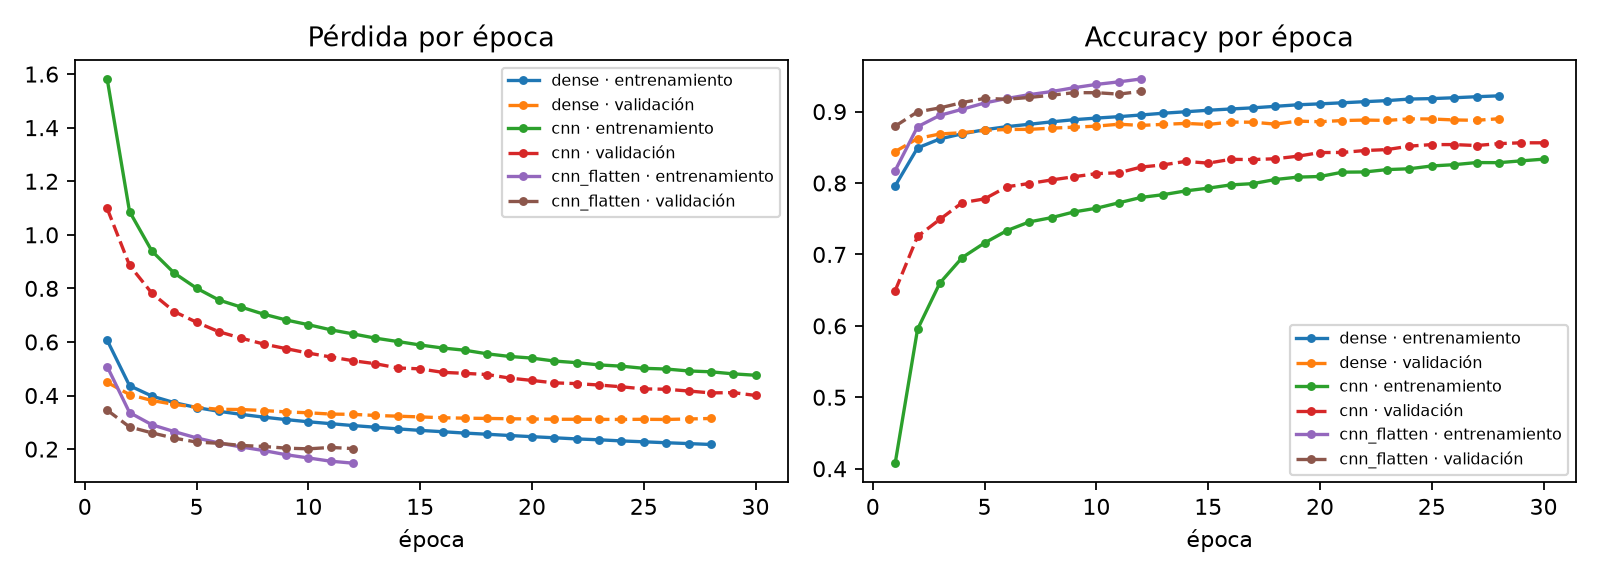

{'modelo_elegido': 'cnn_flatten',
 'razon': 'F1 macro de validación máximo 0.9263; dentro de la tolerancia 0.01: cnn_flatten. Se elige el de menos parámetros: cnn_flatten.',
 'regla': 'Menos parámetros entre los modelos a menos de 0.01 del mejor F1 macro de validación',
 'tomada_antes_de_test': True}

In [5]:
display(Image(filename=str(REPORTS / "curvas.png")))
json.loads((REPORTS / "decision.json").read_text())

## 4. Evaluación en prueba con los modelos guardados

In [6]:
x_test = normalize_images(x_test_raw)
rows, preds = [], {}
for name in ["dense", "cnn", "cnn_flatten"]:
    model = tf.keras.models.load_model(ROOT / f"models/{name}.keras")
    preds[name] = model.predict(x_test, batch_size=256, verbose=0).argmax(axis=1)
    rows.append({"modelo": name, "parametros": model.count_params(),
                 "f1_macro": f1_macro(y_test, preds[name]), "accuracy": accuracy_score(y_test, preds[name])})
table = pd.DataFrame(rows)
saved = json.loads((REPORTS / "cv_metrics.json").read_text())
table["f1_macro_guardado"] = [saved[n]["f1_macro"] for n in table["modelo"]]
table.round(4)

,modelo,parametros,f1_macro,accuracy,f1_macro_guardado
0,dense,50890,0.8761,0.8768,0.8761
1,cnn,19466,0.8474,0.8503,0.8474
2,cnn_flatten,421642,0.9193,0.9199,0.9193


In [7]:
cost = pd.DataFrame({n: saved[n] for n in ["baseline", "dense", "cnn", "cnn_flatten"]}).T
cost[["f1_macro_valid", "f1_macro", "parametros", "epocas", "segundos_entrenamiento", "inferencia_ms_por_imagen", "tamano_kb"]].round(4)

,f1_macro_valid,f1_macro,parametros,epocas,segundos_entrenamiento,inferencia_ms_por_imagen,tamano_kb
baseline,0.0182,0.0182,0.0,NaN,NaN,NaN,NaN
dense,0.8875,0.8761,50890.0,28.0,10.9289,0.0082,619.0967
cnn,0.8537,0.8474,19466.0,30.0,188.1754,0.0285,262.1270
cnn_flatten,0.9263,0.9193,421642.0,12.0,86.8385,0.0319,4979.9453


## 5. Errores por clase

In [8]:
display(per_class(y_test, preds["cnn_flatten"]).round(3))
top_confusions(y_test, preds["cnn_flatten"])

,clase,precision,recall,f1,soporte,errores
0,T-shirt/top,0.849,0.909,0.878,1000,91
1,Trouser,0.985,0.991,0.988,1000,9
2,Pullover,0.889,0.854,0.871,1000,146
3,Dress,0.918,0.931,0.925,1000,69
4,Coat,0.861,0.897,0.879,1000,103
5,Sandal,0.990,0.978,0.984,1000,22
6,Shirt,0.807,0.728,0.766,1000,272
7,Sneaker,0.928,0.990,0.958,1000,10
8,Bag,0.983,0.982,0.982,1000,18
9,Ankle boot,0.988,0.939,0.963,1000,61


,real,predicha,errores
0,Shirt,T-shirt/top,118
1,Shirt,Coat,69
2,T-shirt/top,Shirt,63
3,Pullover,Coat,62
4,Ankle boot,Sneaker,56
5,Pullover,Shirt,52
6,Shirt,Pullover,50
7,Coat,Dress,35


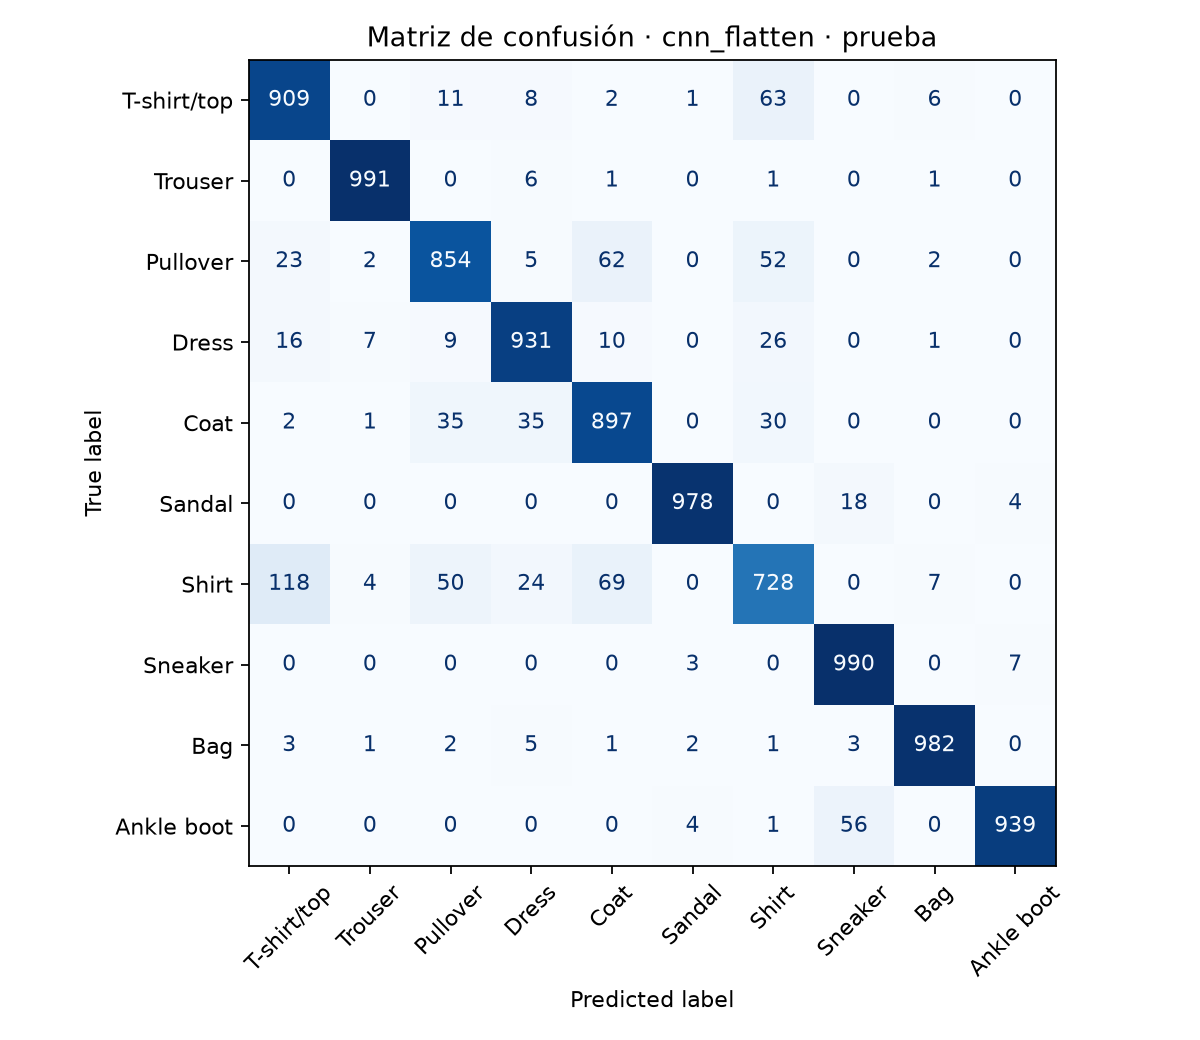

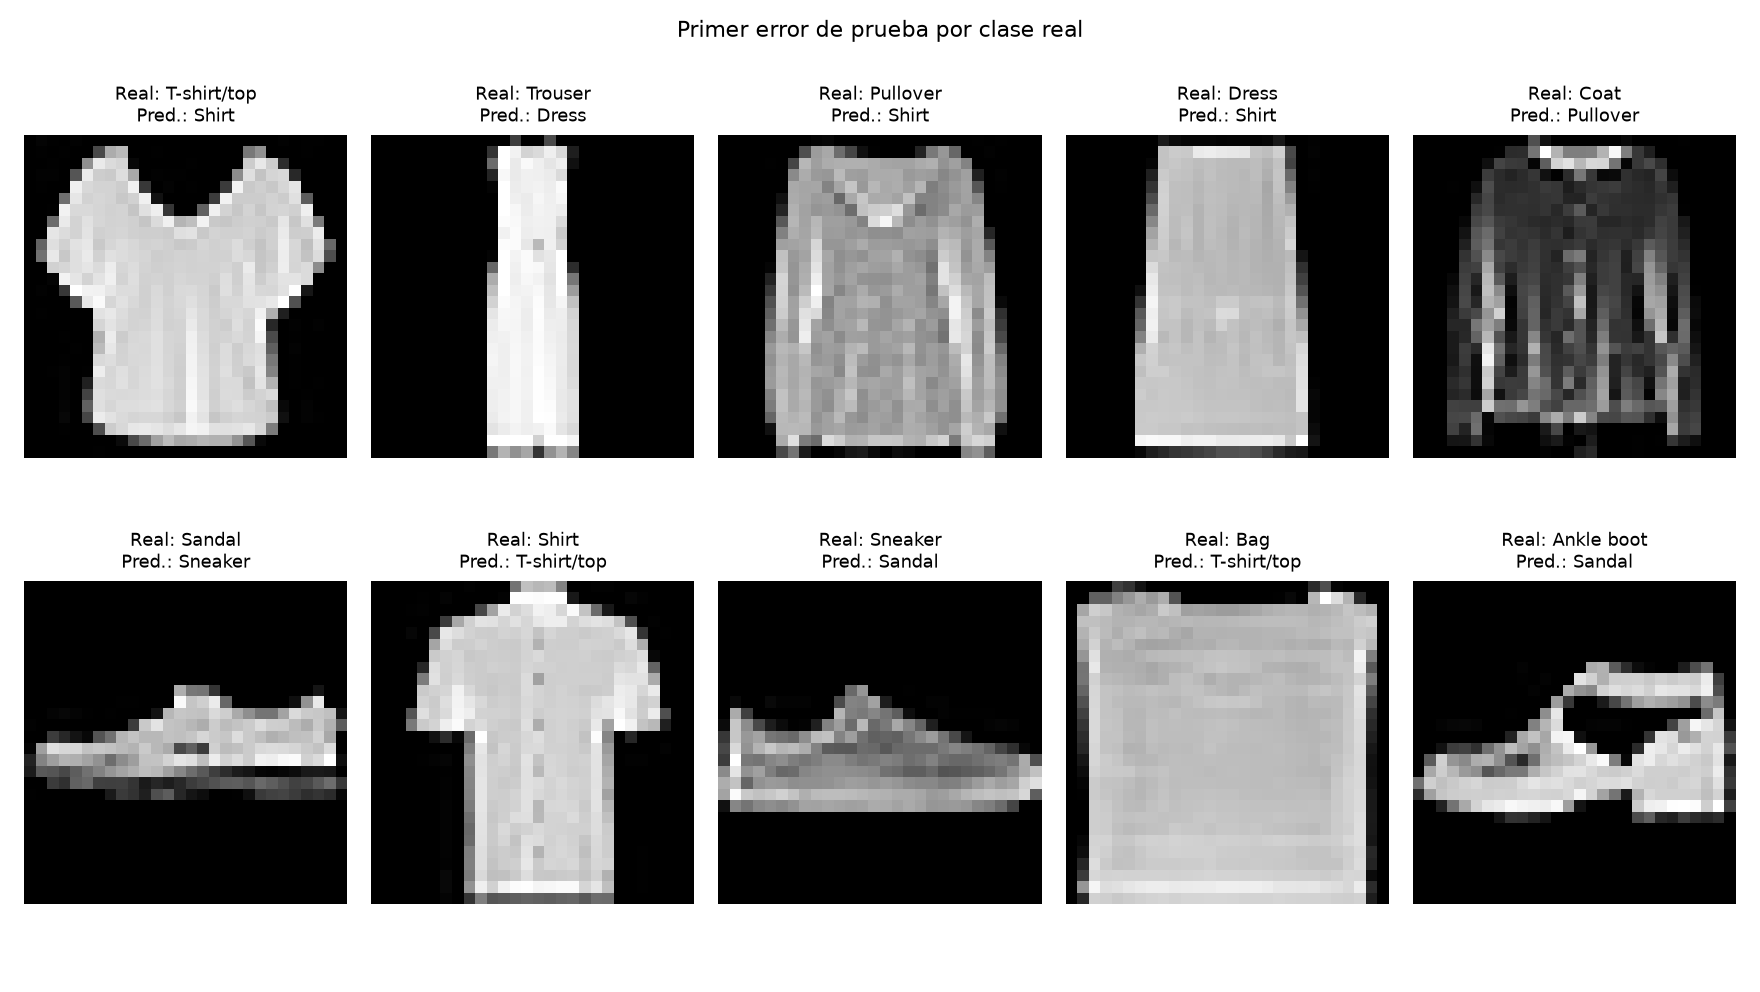

In [9]:
display(Image(filename=str(REPORTS / "confusion_cnn.png")))
Image(filename=str(REPORTS / "cnn_errors.png"))

## 6. Interpretación

| | |
|---|---|
| **Observación** | La CNN con Flatten obtiene F1 macro 0.919 en prueba, frente a 0.876 del denso, 0.847 de la CNN pequeña del proyecto base y 0.018 de la línea base. |
| **Evidencia** | Con 8 épocas la CNN base se quedó en 0.785 (`reports/corrida_8_epocas/`); con 30 seguía mejorando. La que usa Flatten converge en 12 épocas. |
| **Interpretación** | La CNN base pierde la posición espacial al promediar cada mapa. La mayor confusión es Shirt → T-shirt/top (118 casos): son prendas parecidas a 28×28 píxeles y en escala de grises. |
| **Decisión** | Se elige `cnn_flatten`: es el único modelo dentro de 0.01 del mejor F1 de validación. Cuesta 8 veces más parámetros que el denso y 4 veces más inferencia, a cambio de +0.04 de F1 macro. |